# UNO Vision Challenge - IAPR 2026

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from labs.utils.lab_01_utils import *
from skimage.color import rgb2hsv
from explore_hsv import *

## Data loading

In [35]:
import cv2
import numpy as np
from pathlib import Path

folders = [Path("train_images"), Path("test_images"), Path("train_masks"), Path("reference_images")]

images_train, images_test, ref_images = [], [], []
for folder in folders:
    for img_path in folder.glob("*.jpg"):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # from BRG to RGB
        if "train" in str(img_path):
            images_train.append(img)
        elif "test" in str(img_path):
            images_test.append(img)
        else:
            ref_images.append(img)


In [37]:
print(np.shape(ref_images))  # check the data type of the images

(4, 2662, 4000, 3)


## Bounding boxes

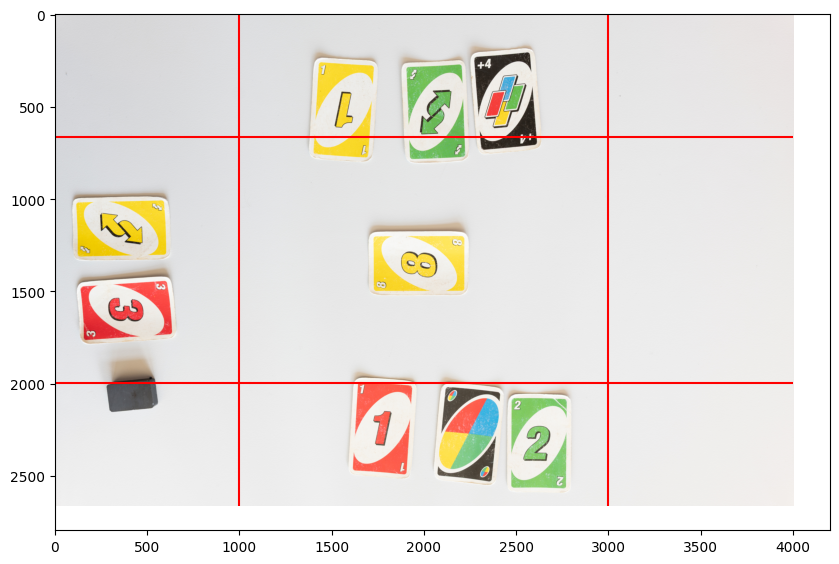

In [4]:
# divide images in 6 overlapping patches
height, width, _ = images_train[8].shape
factor = 1/3

plt.figure(figsize=(10, 10))
plt.imshow(images_train[3])
plt.hlines([height*1/4, height*3/4], 0, width, color="red")
plt.vlines([width*1/4, width*3/4], 0, height, color="red")  

In [5]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    data_h: np.ndarray (M, N)
        Hue channel of input image
    data_s: np.ndarray (M, N)
        Saturation channel of input image
    data_v: np.ndarray (M, N)
        Value channel of input image
    """

    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    # Convert the image from RGB to HSV
    img_hsv = rgb2hsv(img)

    # Extract the HSV channels
    data_h = img_hsv[:,:,0]
    data_s = img_hsv[:,:,1]
    data_v = img_hsv[:,:,2]
    
    return data_h, data_s, data_v

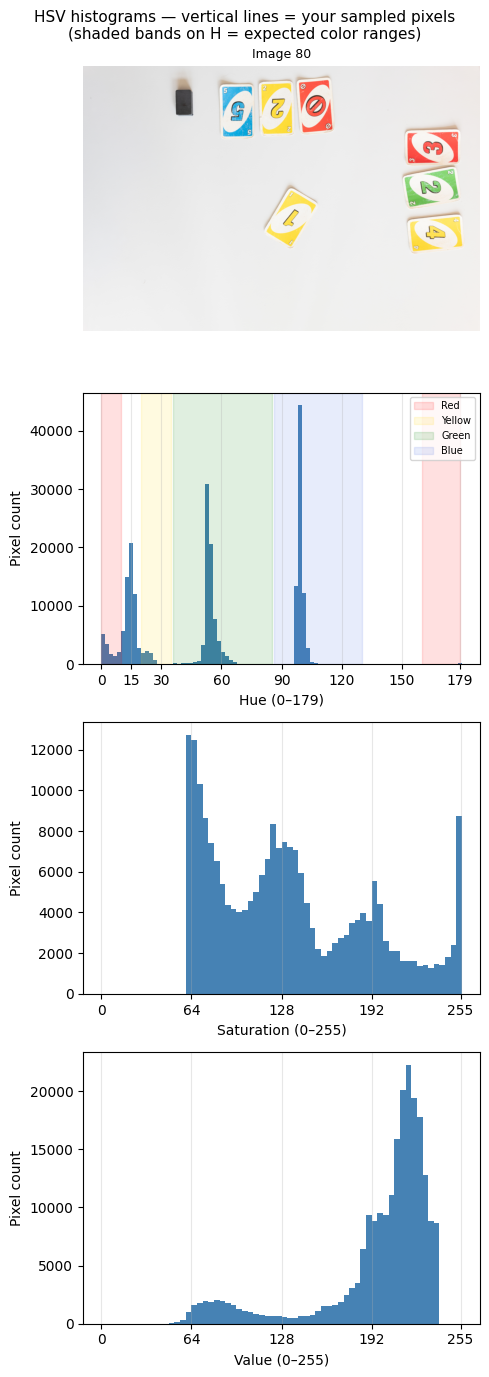

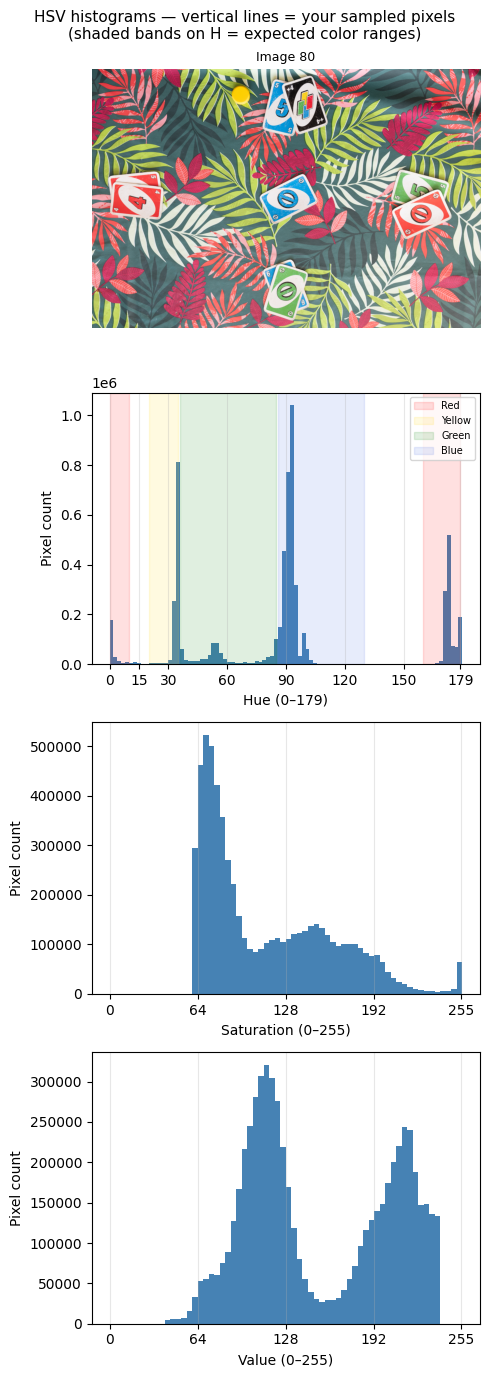

In [10]:
hsv_image = extract_hsv_channels(images_train[80])


# histogram of the HSV channels from
plot_hsv_histograms([cv2.cvtColor(images_train[0], cv2.COLOR_RGB2BGR)], ["Image 80"])
plot_hsv_histograms([cv2.cvtColor(images_train[80], cv2.COLOR_RGB2BGR)], ["Image 80"])

## Segmentation

In [ ]:
"""
Region-merging segmentation for UNO card colour detection.

Algorithm
---------
1. Divide the image into blocks of `block_size x block_size` pixels.
2. Assign each block a colour label using two criteria:
     - Black  : mean Value < BLACK_MAX_V  AND  mean Saturation < BLACK_MAX_S
     - Chromatic (red/yellow/green/blue): circular Hue distance to a
       reference peak < hue_threshold.
   Blocks that match neither criterion are labelled background (0).
3. Upscale block labels to pixel level (nearest-neighbour).
4. Run connected-component labelling per colour class → initial regions.
5. Iteratively merge any region smaller than `min_region_size` pixels into
   its largest neighbouring region until no small regions remain.

Tunable parameters (all in segment()):
  block_size      – side of initial blocks in pixels           (default 16)
  hue_threshold   – max circular Hue distance (0–90) to a peak (default 20)
  min_region_size – minimum surviving region area in pixels    (default 5000)

BLACK_MAX_V / BLACK_MAX_S below control the black detection threshold.
UNO_HUE_PEAKS can be edited to shift hue references (OpenCV scale: 0–179).
"""

import heapq
from collections import defaultdict

import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Hue peaks for chromatic colours (OpenCV H range 0–179) ───────────────────
# Red wraps around 0; we handle that with circular distance.
UNO_HUE_PEAKS = {
    "red":    0,
    "yellow": 25,
    "green":  60,
    "blue":   110,
}

# ── Black detection thresholds (in OpenCV HSV, S and V in 0–255) ─────────────
BLACK_MAX_V = 60   # Value  < this  → dark enough to be black
BLACK_MAX_S = 80   # Saturation < this  → unsaturated enough to be black

_NAMES = ["red", "yellow", "green", "blue", "black"]   # label 1–5
_HUE_PEAKS = np.array(list(UNO_HUE_PEAKS.values()), dtype=float)  # (4,)

_EDGE_COLORS = {
    "red": "red", "yellow": "gold", "green": "lime",
    "blue": "dodgerblue", "black": "white",
}
_OVERLAY_RGB = np.array([
    [210,  50,  40],
    [225, 185,  25],
    [ 35, 140,  55],
    [ 25,  80, 185],
    [ 50,  50,  50],
], dtype=float)  # index i → _NAMES order


def _hue_dist(h, peak):
    """Circular distance between two hue values in [0, 179]."""
    d = abs(h - peak)
    return np.minimum(d, 179 - d)


# ── Main entry point ──────────────────────────────────────────────────────────

def segment(img_rgb, block_size=16, hue_threshold=20, min_region_size=5000):
    """
    Segment img_rgb (H×W×3, uint8 RGB) into UNO colour regions.

    Returns
    -------
    labels : ndarray (H, W), int
        0 = background; 1–5 = UNO colour in _NAMES order.
    boxes  : list of (x, y, w, h, color_name)
        Bounding box + colour name for each surviving region.
    """
    H, W = img_rgb.shape[:2]

    # Step 1 – block-level colour assignment ─────────────────────────────────
    pad_h = (-H) % block_size
    pad_w = (-W) % block_size
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(float)
    padded  = np.pad(img_hsv, ((0, pad_h), (0, pad_w), (0, 0)), mode="edge")
    bH = padded.shape[0] // block_size
    bW = padded.shape[1] // block_size

    # mean H, S, V per block → each (bH, bW)
    blocks = padded.reshape(bH, block_size, bW, block_size, 3).mean(axis=(1, 3))
    mean_H = blocks[:, :, 0]   # hue   (0–179)
    mean_S = blocks[:, :, 1]   # sat   (0–255)
    mean_V = blocks[:, :, 2]   # value (0–255)

    # Black: achromatic + dark — check V and S directly, no hue needed
    is_black = (mean_V < BLACK_MAX_V) & (mean_S < BLACK_MAX_S)

    # Chromatic colours: nearest hue peak within threshold
    hue_dists = np.stack(
        [_hue_dist(mean_H, p) for p in _HUE_PEAKS], axis=2
    )                                                    # (bH, bW, 4)
    best_hue_idx = hue_dists.argmin(axis=2)             # (bH, bW)
    min_hue_dist = hue_dists.min(axis=2)                # (bH, bW)
    is_chromatic = min_hue_dist < hue_threshold

    # Combine: black takes priority over chromatic
    block_labels = np.zeros((bH, bW), dtype=np.int32)
    block_labels[is_chromatic] = best_hue_idx[is_chromatic] + 1  # labels 1–4
    block_labels[is_black]     = 5                                # label 5 = black

    # Step 2 – upscale to pixel level ────────────────────────────────────────
    labels = np.kron(block_labels, np.ones((block_size, block_size), dtype=np.int32))[:H, :W]

    # Step 3 – connected components per colour class ──────────────────────────
    region_map   = np.zeros((H, W), dtype=np.int32)
    region_color = {}   # region_id → colour label (1–5)
    next_rid = 1

    for clbl in range(1, len(_NAMES) + 1):
        cc, n = ndimage.label(labels == clbl)
        for i in range(1, n + 1):
            region_map[cc == i] = next_rid
            region_color[next_rid] = clbl
            next_rid += 1

    # Step 4 – merge small regions into their largest neighbour ──────────────
    changed = True
    while changed:
        changed = False
        for rid in list(region_color):
            mask = region_map == rid
            if mask.sum() >= min_region_size:
                continue
            # find region ids on the 1-pixel border
            border = ndimage.binary_dilation(mask) & ~mask
            neighbours = np.unique(region_map[border])
            neighbours = neighbours[neighbours > 0]
            if len(neighbours) == 0:
                region_map[mask] = 0
            else:
                best = max(neighbours, key=lambda n: int((region_map == n).sum()))
                region_map[mask] = best
            del region_color[rid]
            changed = True

    # Step 5 – rebuild pixel labels and collect bounding boxes ────────────────
    final = np.zeros((H, W), dtype=np.int32)
    boxes = []
    for rid, clbl in region_color.items():
        mask = region_map == rid
        final[mask] = clbl
        ys, xs = np.where(mask)
        boxes.append((
            int(xs.min()), int(ys.min()),
            int(xs.max() - xs.min() + 1),
            int(ys.max() - ys.min() + 1),
            _NAMES[clbl - 1],
        ))

    return final, boxes


# ── Visualisation helper ──────────────────────────────────────────────────────

# Matplotlib colours matching each chromatic UNO colour
_MPL_COLORS = {"red": "red", "yellow": "gold", "green": "limegreen", "blue": "dodgerblue"}


def visualize(img_rgb, labels, boxes, hue_threshold=20,
              title="Region-merging segmentation"):
    """
    Three-panel figure:
      1. Original image
      2. Colour-overlay with bounding boxes
      3. Hue histogram of the image with reference peaks (vertical lines)
         and accepted hue bands (shaded regions) for each chromatic colour.
    """
    # ── panel 1 & 2: overlay ────────────────────────────────────────────────
    overlay = img_rgb.astype(float).copy()
    alpha = 0.45
    for clbl in range(1, len(_NAMES) + 1):
        mask = (labels == clbl)[:, :, None]
        overlay = np.where(mask, (1 - alpha) * overlay + alpha * _OVERLAY_RGB[clbl - 1], overlay)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(19, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    for x, y, w, h, name in boxes:
        ec = _EDGE_COLORS[name]
        rect = mpatches.Rectangle((x, y), w, h, linewidth=2, edgecolor=ec, facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x + 4, y + 16, name, color=ec, fontsize=8, fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.4, lw=0))
    axes[1].set_title(f"Segmented ({len(boxes)} regions)")
    axes[1].axis("off")

    # ── panel 3: hue histogram ───────────────────────────────────────────────
    ax = axes[2]
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    # Exclude achromatic (low-sat) and very dark/bright pixels — same filter as plot_hsv_histograms
    sat_mask = img_hsv[:, :, 1] > 60
    val_mask = (img_hsv[:, :, 2] > 40) & (img_hsv[:, :, 2] < 240)
    hues = img_hsv[:, :, 0][sat_mask & val_mask].flatten()

    ax.hist(hues, bins=90, range=(0, 180), color="steelblue", edgecolor="none", alpha=0.7)

    for name, peak in UNO_HUE_PEAKS.items():
        c = _MPL_COLORS[name]
        # Shaded acceptance band (circular wrap for red)
        lo, hi = peak - hue_threshold, peak + hue_threshold
        if lo < 0:                          # red wraps below 0
            ax.axvspan(0,       hi,      alpha=0.20, color=c)
            ax.axvspan(179 + lo, 180,    alpha=0.20, color=c)
        elif hi > 179:                      # (would wrap above 179)
            ax.axvspan(lo,  180,          alpha=0.20, color=c)
            ax.axvspan(0,   hi - 179,     alpha=0.20, color=c)
        else:
            ax.axvspan(lo, hi, alpha=0.20, color=c)
        # Vertical line at the peak
        ax.axvline(peak, color=c, linewidth=2, label=name)

    ax.set_xlabel("Hue (OpenCV 0–179)")
    ax.set_ylabel("Pixel count (sat > 40)")
    ax.set_title("Hue histogram + colour bands")
    ax.set_xlim(0, 179)
    ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


In [28]:
def visualize_hist(img_rgb, hue_threshold=20,
              title="Region-merging segmentation"):
    """
    Three-panel figure:
      1. Original image
      2. Colour-overlay with bounding boxes
      3. Hue histogram of the image with reference peaks (vertical lines)
         and accepted hue bands (shaded regions) for each chromatic colour.
    """
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    # Only use pixels with enough saturation to have a meaningful hue
    sat_mask = img_hsv[:, :, 1] > 60
    val_mask = (img_hsv[:, :, 2] > 40) & (img_hsv[:, :, 2] < 240)
    hues = img_hsv[:, :, 0][sat_mask & val_mask].flatten()

    plt.hist(hues, bins=90, range=(0, 180), color="steelblue", edgecolor="none", alpha=0.7)

    for name, peak in UNO_HUE_PEAKS.items():
        c = _MPL_COLORS[name]
        # Shaded acceptance band (circular wrap for red)
        lo, hi = peak - hue_threshold, peak + hue_threshold
        if lo < 0:                          # red wraps below 0
            plt.axvspan(0,       hi,      alpha=0.20, color=c)
            plt.axvspan(179 + lo, 180,    alpha=0.20, color=c)
        elif hi > 179:                      # (would wrap above 179)
            plt.axvspan(lo,  180,          alpha=0.20, color=c)
            plt.axvspan(0,   hi - 179,     alpha=0.20, color=c)
        else:
            plt.axvspan(lo, hi, alpha=0.20, color=c)
        # Vertical line at the peak
        plt.axvline(peak, color=c, linewidth=2, label=name)

    plt.set_xlabel("Hue (OpenCV 0–179)")
    plt.set_ylabel("Pixel count (sat > 40)")
    plt.set_title("Hue histogram + colour bands")
    plt.set_xlim(0, 179)
    plt.legend(fontsize=8)

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xlabel'

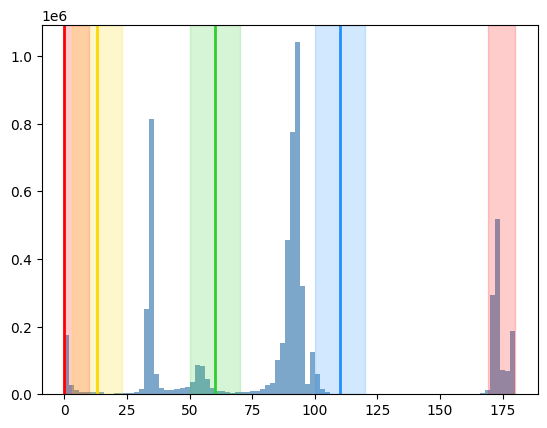

In [34]:
UNO_HUE_PEAKS = {
    "red":    0,
    "yellow": 13,
    "green":  60,
    "blue":   110,
}

visualize_hist(images_train[80], hue_threshold=10)

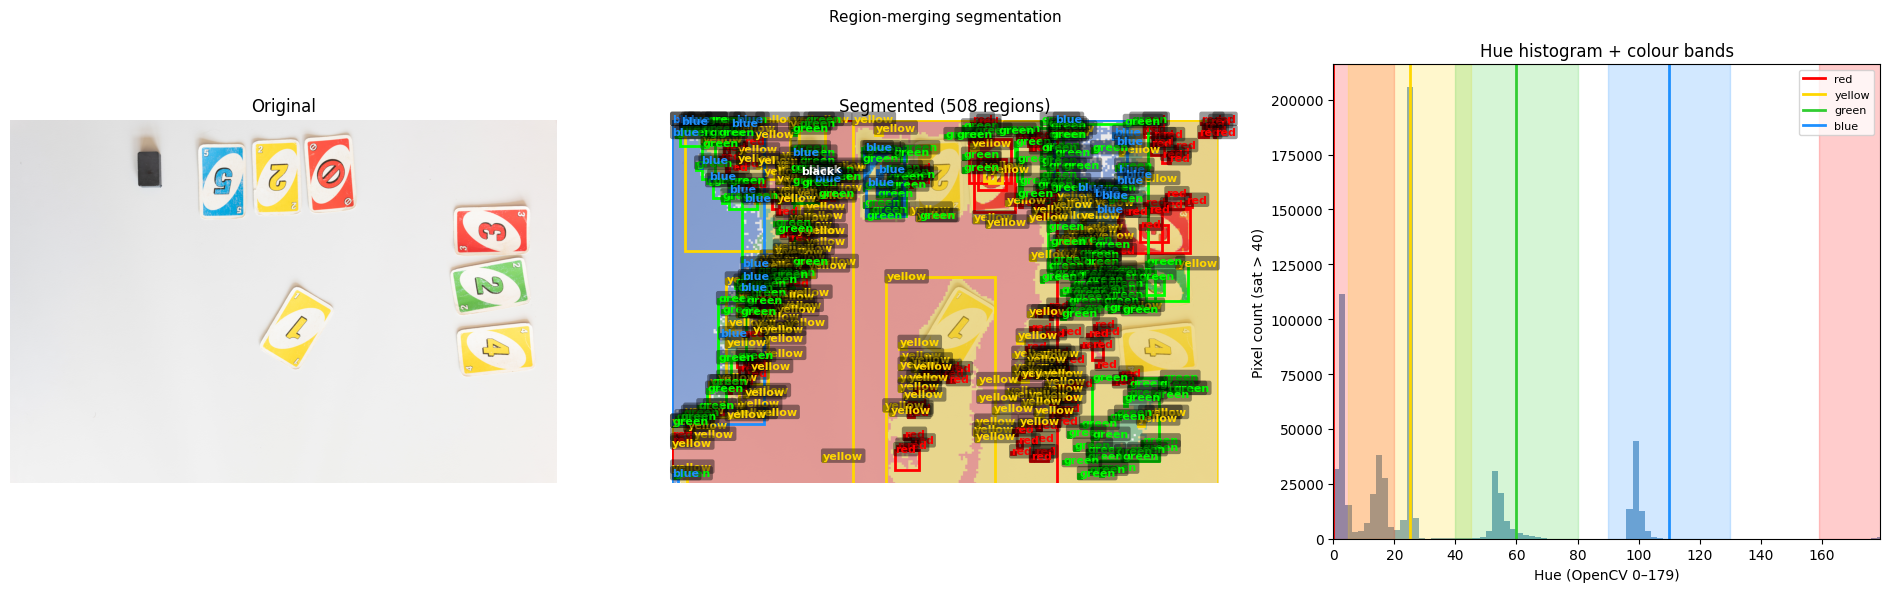

In [24]:
labels, boxes = segment(images_train[0], block_size=16, min_region_size=500)
visualize(images_train[0], labels, boxes, title="Region-merging segmentation")

## Automatic Hue Peak Detection

In [ ]:
# Constrained hue search windows per colour (OpenCV scale 0–179).
# Red wraps around 0, so its range is [175, 179] ∪ [0, 5].
COLOR_RANGES = {
    "red":    (175,  5),
    "yellow": ( 23, 27),
    "green":  ( 55, 62),
    "blue":   ( 98,108),
}

def detect_hue_peaks(image_rgb, smooth_window=7):
    """
    For each colour, find the hue bin with the highest count
    within its predefined search window.
    """
    hist = np.zeros(180, dtype=float)
    hsv  = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    mask = (hsv[:, :, 1] > 60) & (hsv[:, :, 2] > 40) & (hsv[:, :, 2] < 240)
    h, _ = np.histogram(hsv[:, :, 0][mask].ravel(), bins=180, range=(0, 180))
    hist += h

    kernel   = np.ones(smooth_window) / smooth_window
    smoothed = np.convolve(hist, kernel, mode='same')

    peaks = {}
    for name, (lo, hi) in COLOR_RANGES.items():
        if lo > hi:  # red wraps around 0
            indices = np.concatenate([np.arange(lo, 180), np.arange(0, hi + 1)])
        else:
            indices = np.arange(lo, hi + 1)
        peaks[name] = int(indices[smoothed[indices].argmax()])

    return peaks, hist, smoothed


SMOOTH_WINDOW = 7
UNO_HUE_PEAKS, hist, smoothed = detect_hue_peaks(images_train[80], smooth_window=SMOOTH_WINDOW)
print("Detected peaks:", UNO_HUE_PEAKS)

# Plot
mpl_colors = {"red": "red", "yellow": "gold", "green": "limegreen", "blue": "dodgerblue"}
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(180), hist, color="steelblue", alpha=0.4, label="raw")
ax.plot(smoothed, color="navy", linewidth=1.5, label=f"smoothed (window={SMOOTH_WINDOW})")
for name, (lo, hi) in COLOR_RANGES.items():
    c = mpl_colors[name]
    if lo > hi:
        ax.axvspan(lo, 180, alpha=0.15, color=c)
        ax.axvspan(0,  hi,  alpha=0.15, color=c)
    else:
        ax.axvspan(lo, hi, alpha=0.15, color=c, label=f"{name} [{lo}–{hi}]")
    ax.axvline(UNO_HUE_PEAKS[name], color=c, linewidth=2, linestyle="--",
               label=f"peak={UNO_HUE_PEAKS[name]}")
ax.set_xlabel("Hue (OpenCV 0–179)")
ax.set_ylabel("Pixel count")
ax.set_xlim(0, 179)
ax.legend(fontsize=7, ncol=2)
ax.set_title("Hue histogram — constrained peak search per colour")
plt.tight_layout()
plt.show()


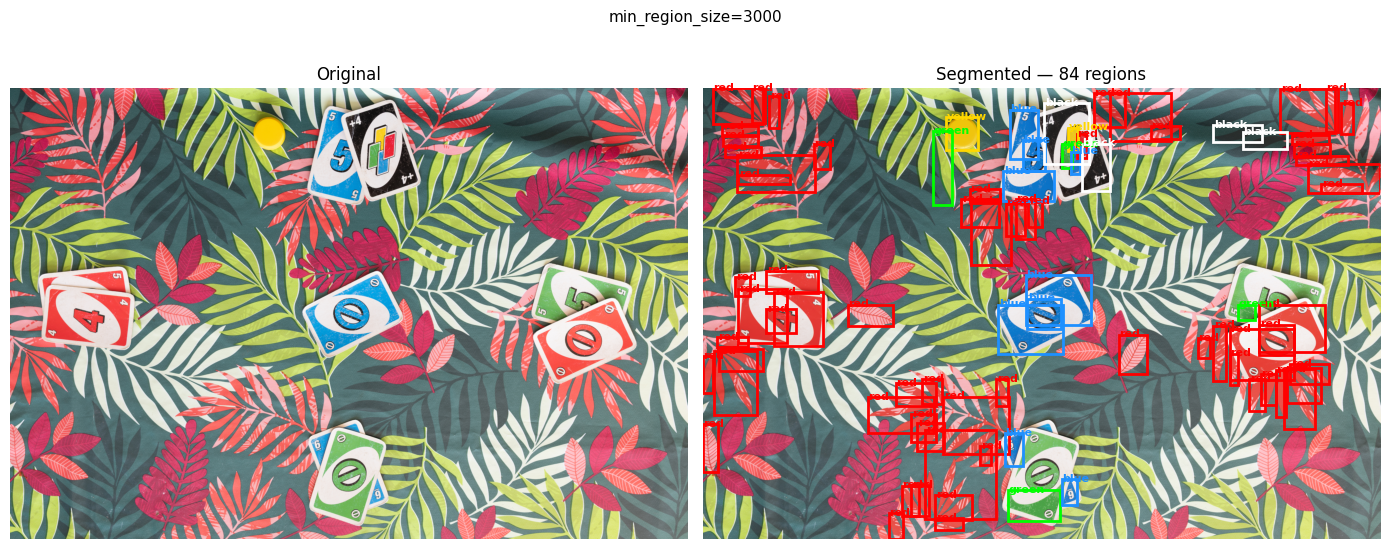

In [47]:
from scipy import ndimage

# ── Thresholds to tune ────────────────────────────────────────────────────────
MIN_SATURATION  = 120   # raised: vivid card colours have S > 150, muted backgrounds < 100
MIN_VALUE       = 40    # reject very dark pixels
BLACK_MAX_V     = 60    # value  threshold for black
BLACK_MAX_S     = 80    # sat    threshold for black
MIN_REGION_SIZE = 3000  # minimum region area in pixels to keep

COLOR_NAMES = ["red", "yellow", "green", "blue", "black"]
OVERLAY_RGB  = np.array([[210,50,40],[225,185,25],[35,140,55],[25,80,185],[50,50,50]], dtype=float)
EDGE_COLORS  = {"red":"red","yellow":"gold","green":"lime","blue":"dodgerblue","black":"white"}


def apply_color_mask(img_rgb):
    """
    Hard hue-threshold every pixel using COLOR_RANGES.
    Returns label map: 0 = background, 1–4 = chromatic colours, 5 = black.
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    labels  = np.zeros(img_rgb.shape[:2], dtype=np.int32)

    chromatic_mask = (S > MIN_SATURATION) & (V > MIN_VALUE)
    for i, (name, (lo, hi)) in enumerate(COLOR_RANGES.items(), start=1):
        hue_mask = (H >= lo) | (H <= hi) if lo > hi else (H >= lo) & (H <= hi)
        labels[hue_mask & chromatic_mask] = i

    labels[(V < BLACK_MAX_V) & (S < BLACK_MAX_S)] = 5  # black overwrites
    return labels


def segment(img_rgb, min_region_size=MIN_REGION_SIZE):
    """
    Threshold → connected components → drop regions < min_region_size.
    Returns label map and list of (x, y, w, h, color_name).
    """
    raw   = apply_color_mask(img_rgb)
    H, W  = img_rgb.shape[:2]
    final = np.zeros((H, W), dtype=np.int32)
    boxes = []

    for clbl in range(1, len(COLOR_NAMES) + 1):
        cc, n = ndimage.label(raw == clbl)
        sizes = np.bincount(cc.ravel())          # all region sizes in one pass
        for i in range(1, n + 1):
            if sizes[i] < min_region_size:
                continue
            region = cc == i
            final[region] = clbl
            ys, xs = np.where(region)
            boxes.append((int(xs.min()), int(ys.min()),
                          int(xs.max()-xs.min()+1), int(ys.max()-ys.min()+1),
                          COLOR_NAMES[clbl - 1]))
    return final, boxes


def visualize(img_rgb, labels, boxes, title=""):
    overlay = img_rgb.astype(float).copy()
    for clbl in range(1, len(COLOR_NAMES) + 1):
        mask = (labels == clbl)[:, :, None]
        overlay = np.where(mask, 0.55*overlay + 0.45*OVERLAY_RGB[clbl-1], overlay)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img_rgb);  axes[0].set_title("Original");  axes[0].axis("off")
    axes[1].imshow(overlay);  axes[1].set_title(f"Segmented — {len(boxes)} regions"); axes[1].axis("off")
    for x, y, w, h, name in boxes:
        ec = EDGE_COLORS[name]
        axes[1].add_patch(plt.Rectangle((x,y), w, h, lw=2, edgecolor=ec, facecolor="none"))
        axes[1].text(x+4, y+16, name, color=ec, fontsize=8, fontweight="bold")
    fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()


# ── Test on one image ─────────────────────────────────────────────────────────
labels, boxes = segment(images_train[80], min_region_size=MIN_REGION_SIZE)
visualize(images_train[80], labels, boxes, title=f"min_region_size={MIN_REGION_SIZE}")


Detected peaks: {'red': 3, 'yellow': 23, 'green': 55, 'blue': 100}


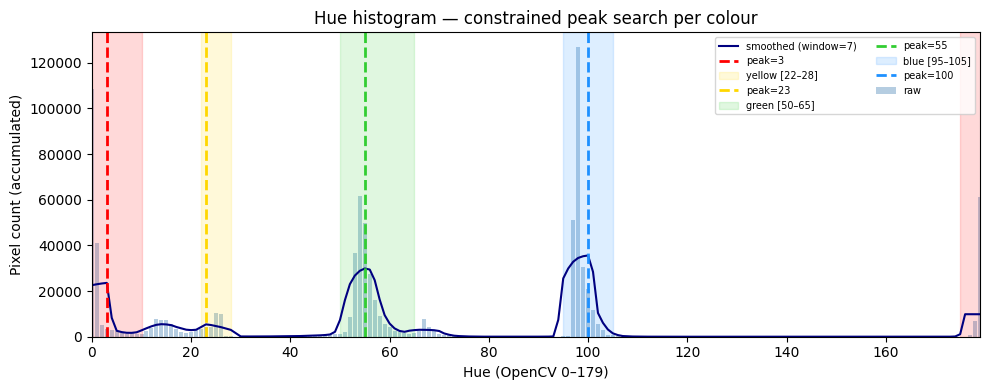

In [42]:
SMOOTH_WINDOW = 7
UNO_HUE_PEAKS, hist, smoothed = detect_hue_peaks(ref_images[2], smooth_window=SMOOTH_WINDOW)
print("Detected peaks:", UNO_HUE_PEAKS)

# Plot
mpl_colors = {"red": "red", "yellow": "gold", "green": "limegreen", "blue": "dodgerblue"}
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(180), hist, color="steelblue", alpha=0.4, label="raw")
ax.plot(smoothed, color="navy", linewidth=1.5, label=f"smoothed (window={SMOOTH_WINDOW})")
for name, (lo, hi) in COLOR_RANGES.items():
    c = mpl_colors[name]
    if lo > hi:
        ax.axvspan(lo, 180, alpha=0.15, color=c)
        ax.axvspan(0,  hi,  alpha=0.15, color=c)
    else:
        ax.axvspan(lo, hi, alpha=0.15, color=c, label=f"{name} [{lo}–{hi}]")
    ax.axvline(UNO_HUE_PEAKS[name], color=c, linewidth=2, linestyle="--",
               label=f"peak={UNO_HUE_PEAKS[name]}")
ax.set_xlabel("Hue (OpenCV 0–179)")
ax.set_ylabel("Pixel count (accumulated)")
ax.set_xlim(0, 179)
ax.legend(fontsize=7, ncol=2)
ax.set_title("Hue histogram — constrained peak search per colour")
plt.tight_layout()
plt.show()